# <center><strong>Bank Customer Churn Analysis</strong></center>
--------------------------------


#### **By Mohamed Jamyl**

http://linkedin.com/company/gray-matter-da

http://linkedin.com/in/mohamed-jamyl

https://www.kaggle.com/mohamedjamyl

https://github.com/Mohamed-Jamyl

-------------------------

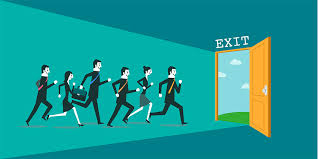

In [1]:
from IPython.display import Image
Image(filename='Bank.jpeg')

--------------------------------
--------------------------------
--------------------------------

## **Import Libraries**


In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt 
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [3]:
def pie(data,col):
    data[col].value_counts().plot.pie(autopct='%0.2f%%')
    plt.show()

def countplot(data,col):
    sns.countplot(x=col, data=data)
    plt.show()

def kde(data, col):
    plt.figure(figsize=(14,	4))
    sns.kdeplot(data[col], fill=True,	color='red', alpha=0.6)
    plt.title(f'Kernel Density Estimate(KDE) - {col}',	fontsize=16)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

---------------------------------------
---------------------------------------
---------------------------------------

## **Exploratory Data Analysis (EDA)**

### **Initial Data Understanding**

 - **Data loading and Inspection**
 - **Data Types**
 - **Missing Values**
 - **Duplicates**

-------------------------

In [4]:
df = pd.read_csv("bank customer churn dataset.csv")

In [5]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [6]:
df.shape

(10000, 14)

In [7]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [9]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [10]:
df.duplicated().sum()

0

------------------------
------------------------
### **Data Cleaning**
------------------------

In [11]:
df.rename(columns={'HasCrCard': 'Has credit card','IsActiveMember':'Is Active Member','CreditScore':'Credit Score',
                   'NumOfProducts':'Number Of Products','EstimatedSalary':'Estimated Salary','Exited':'Churned'} ,inplace=True)

In [12]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], inplace=True, axis=1)

-----------------------------------------
-----------------------------------------

### **Basic Statistical Overview**
-------------------------------------------
- Summary Statistical : **describe()**

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Credit Score,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
Number Of Products,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
Has credit card,10000.0,0.705500,0.455840,0.00,0.00,1.000,1.0000,1.00
Is Active Member,10000.0,0.515100,0.499797,0.00,0.00,1.000,1.0000,1.00
Estimated Salary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48
Churned,10000.0,0.203700,0.402769,0.00,0.00,0.000,0.0000,1.00


--------------------------------

- Summary Statistical : **value_counts()**
----------------------

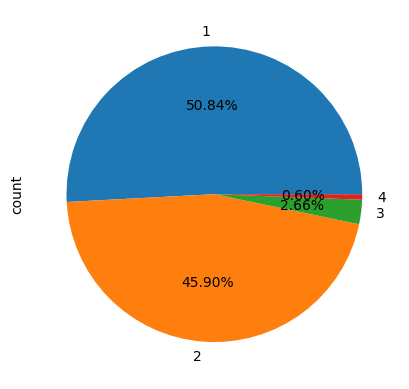

In [14]:
df['Number Of Products'].value_counts().plot.pie(autopct='%0.2f%%')
plt.show()

-----------------------------------

C:\Users\RPC\AppData\Local\Temp\ipykernel_3976\1213901015.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Geography', data=df, palette=['green','blue','yellow'])


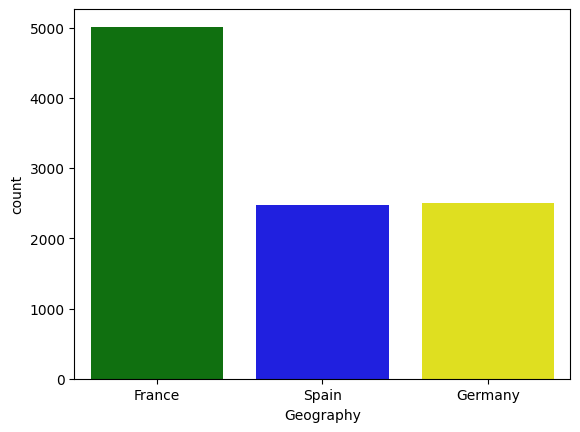

In [15]:
sns.countplot(x='Geography', data=df, palette=['green','blue','yellow'])
plt.show()

-----------------------------------

C:\Users\RPC\AppData\Local\Temp\ipykernel_3976\457633866.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Has credit card', data=df, palette=['green','blue'])


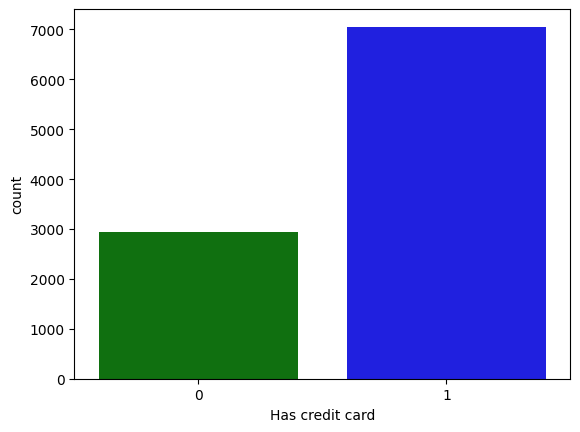

In [16]:
sns.countplot(x='Has credit card', data=df, palette=['green','blue'])    
plt.show()

-----------------------------------

C:\Users\RPC\AppData\Local\Temp\ipykernel_3976\2796008230.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Is Active Member', data=df, palette=['orange','yellow'])


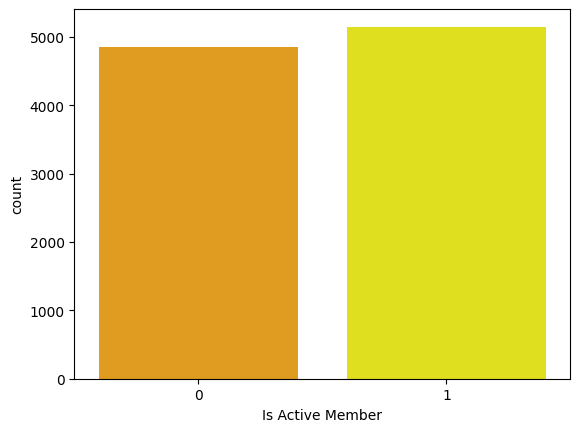

In [17]:
sns.countplot(x='Is Active Member', data=df, palette=['orange','yellow'])
plt.show()

-----------------------------------

### **Checking Correlation between the features**

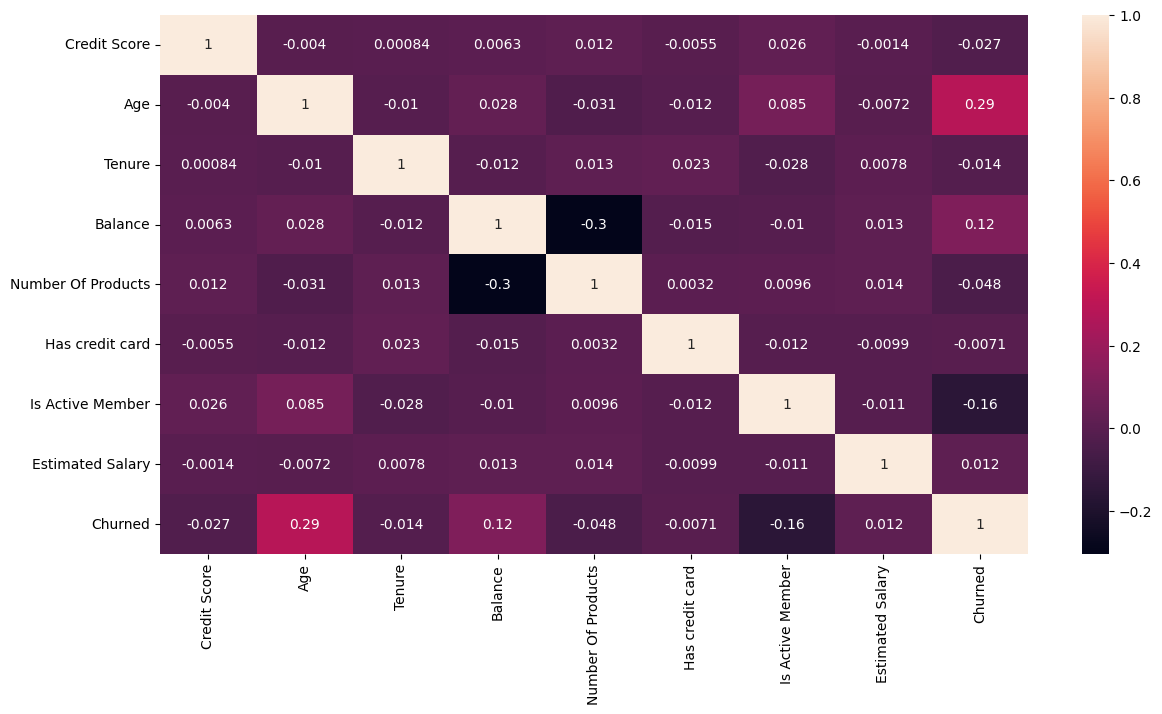

In [18]:
plt.figure(figsize=(14,	7))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)
plt.show()

- ##### There is a **normal positive correlation (0.3)** between **Age** and **Exited** 
- ##### There is a **normal negative correlation (-0.3)** between **Balance** and **Number Of Products** 


------------------------------------------
------------------------------------------

## **Feature Extraction**

-----------------------------

In [19]:
def ageGroup(age):
    age = int(age)
    if age <= 40:
        return 'Young Adults'
    elif age > 40 and age < 60:
        return 'Middle-aged Adults'
    else :
        return 'Old Adults'
    
df['Age group'] = df['Age'].apply(lambda x : ageGroup(x))

In [20]:
df['Age group'].value_counts()

Age group
Young Adults          6419
Middle-aged Adults    3055
Old Adults             526
Name: count, dtype: int64

----------------------------------

In [21]:
def balanceGroup(balance):
    balance = float(balance)
    if balance > 0:
        return 'Funded account'
    elif balance == 0:
        return 'Empty account'
    else:
        return 'Overdrawn account'

df['Balance category'] = df['Balance'].apply(lambda x : balanceGroup(x))

In [22]:
df['Balance category'].value_counts()

Balance category
Funded account    6383
Empty account     3617
Name: count, dtype: int64

-----------------------------

In [23]:
def activeGroup(actAcc):
    actAcc = int(actAcc)
    if actAcc == 1:
        return 'Active account'
    else:
        return 'Dormant account'

df['Is Active Member'] = df['Is Active Member'].apply(lambda x : activeGroup(x))

In [24]:
df['Is Active Member'].value_counts()

Is Active Member
Active account     5151
Dormant account    4849
Name: count, dtype: int64

------------------------------------

In [25]:
def cardGroup(card):
    card = int(card)
    if card == 1:
        return 'Has a card'
    else:
        return 'No'

df['Has credit card'] = df['Has credit card'].apply(lambda x : cardGroup(x))

In [26]:
df['Has credit card'].value_counts()

Has credit card
Has a card    7055
No            2945
Name: count, dtype: int64

--------------------------------

In [27]:
def categorize_credit(score):
    if score < 580:
        return 'Poor'
    elif score < 670:
        return 'Fair'
    elif score < 740:
        return 'Good'
    elif score < 800:
        return 'Very Good'
    else:
        return 'Excellent'

df['Credit Score Category'] = df['Credit Score'].apply(categorize_credit)

In [28]:
df['Credit Score Category'].value_counts()

Credit Score Category
Fair         3331
Good         2428
Poor         2362
Very Good    1224
Excellent     655
Name: count, dtype: int64

-----------------------

In [29]:
def Churned(exit):
    exit = int(exit)
    if exit == 1:
        return 'Exited'
    else:
        return 'Stayed'

df['Churned'] = df['Churned'].apply(lambda x : Churned(x))

In [30]:
df['Churned'].value_counts()

Churned
Stayed    7963
Exited    2037
Name: count, dtype: int64

-----------------------

In [31]:
def categorize_Estimated_Salary(Salary):
    if Salary < 50000:
        return 'Low Salary'
    elif Salary < 100000:
        return 'Medium Salary'
    elif Salary < 150000:
        return 'High Salary'
    else:
        return 'Very High Salary'

df['Estimated Salary Category'] = df['Estimated Salary'].apply(categorize_Estimated_Salary)

In [32]:
df['Estimated Salary Category'].value_counts()

Estimated Salary Category
High Salary         2555
Medium Salary       2537
Very High Salary    2455
Low Salary          2453
Name: count, dtype: int64

------------------------------------

In [33]:
df['BalanceSalaryRatio'] = df['Balance'] / df['Estimated Salary']

In [34]:
df[['Balance', 'Estimated Salary', 'BalanceSalaryRatio']].head()

,Balance,Estimated Salary,BalanceSalaryRatio
0,0.00,101348.88,0.000000
1,83807.86,112542.58,0.744677
2,159660.80,113931.57,1.401375
3,0.00,93826.63,0.000000
4,125510.82,79084.10,1.587055


In [35]:
#df.to_excel('bank customer churn new dataset.xlsx',index=False)

----------------------------
----------------------------


## **Analysis**

------------------------------
- ### ***Analysis of Gender and Age vs Churn***
------------------------------- 

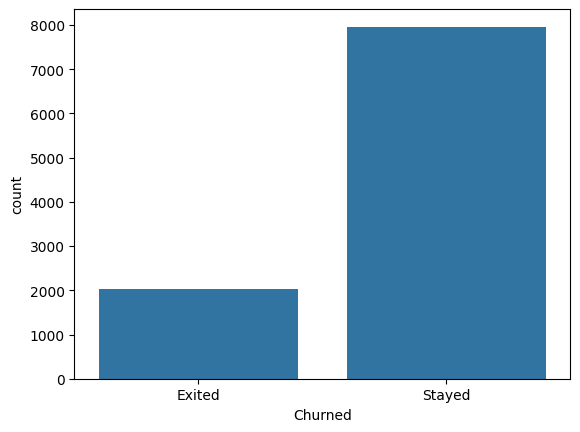

In [36]:
countplot(df,'Churned')

In [37]:
p_churn = len(df[df['Churned']=='Exited'])/len(df)
print(f'{p_churn*100:.2f} %')

20.37 %


- #### **Age distribution**

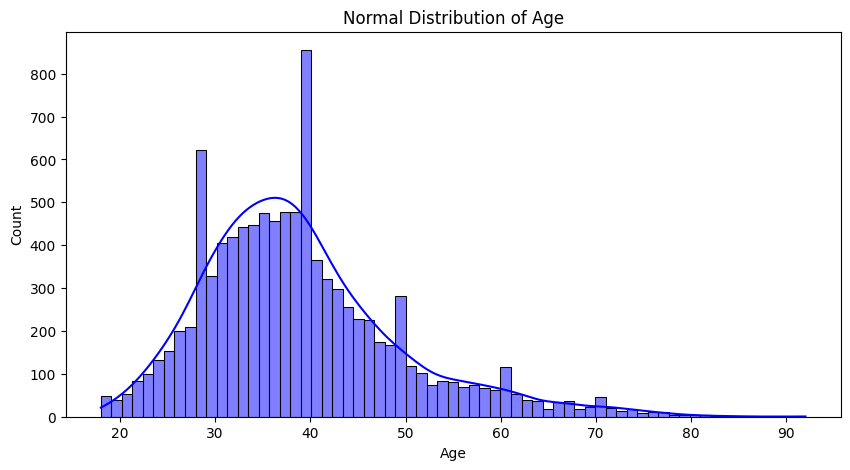

In [38]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Age'], kde=True, color='blue')
plt.title('Normal Distribution of Age')
plt.show()

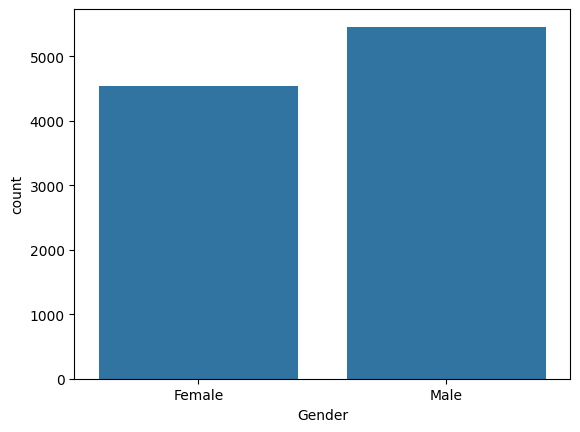

In [39]:
countplot(df,'Gender')

- #### **Age distibution by gender**

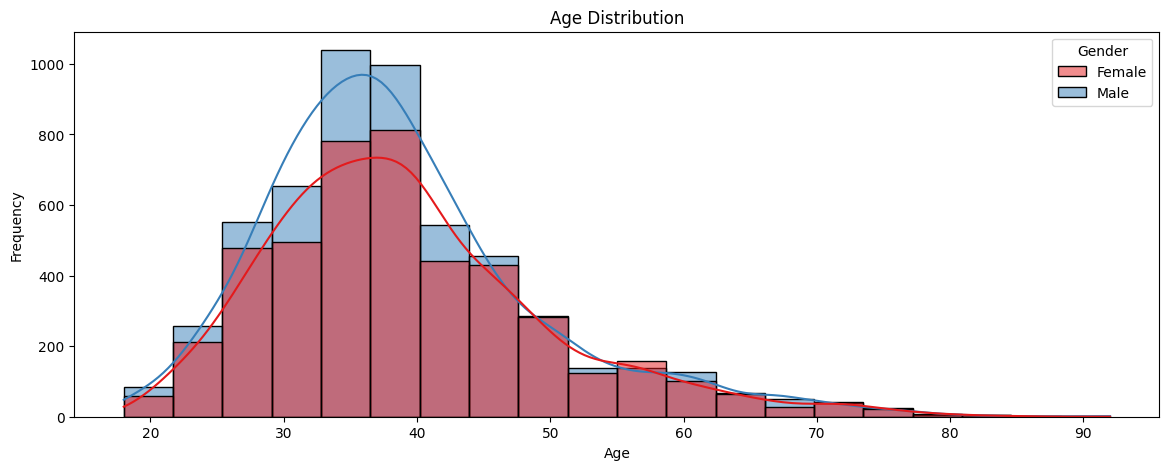

In [40]:
plt.figure(figsize=(14, 5))
sns.histplot(data=df, x='Age', hue='Gender', kde=True, bins=20, palette='Set1')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

##### **The male age distribution is represented by the blue bars and curve.**

##### **The peak frequency for males is slightly older than for females, peaking around the late 30s to early 40s.**

##### **The count of males is consistently higher than females across the majority of the age range shown.**


- #### **Comparison of Churn probability between Males and Females**

In [ ]:
# for male
p_male_given_churned = len(df[(df['Gender']=='Male') & (df['Churned']=='Exited')]) / len(df[df['Churned']=='Exited']) # P(male ∣ churned)
print(f'P(male ∣ churned) : {p_male_given_churned*100:.2f} %')

P(male ∣ churned) : 44.08 %


In [55]:
p_intersection_male_churn = p_churn * p_male_given_churned
print(f'P(churned ∩ male) : {p_intersection_male_churn*100:.2f} %')

P(churned ∩ male) : 8.98 %


In [ ]:
print(f'P(churned ∩ female) : {(p_churn - p_intersection_male_churn)*100:.2f} %')

P(churned ∩ female) : 11.39 %


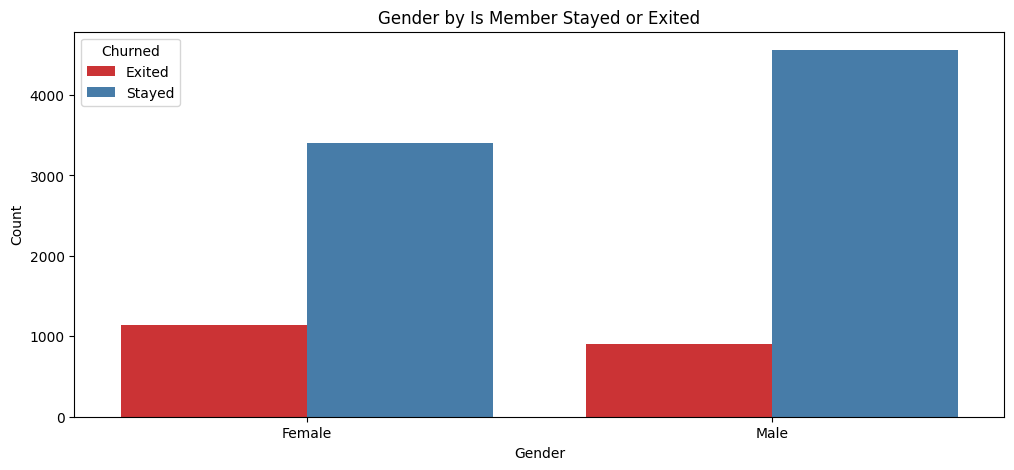

In [ ]:
plt.figure(figsize=(12, 5))
sns.countplot(data = df, x = 'Gender', hue='Churned',palette='Set1')
plt.title('Gender by Is Member Stayed or Exited')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

##### **A higher total number of males are in the dataset than females, as the "Stayed" bar for males is much taller than the "Stayed" bar for females, and the same is true for the "Exited" bars.**

##### **The chart clearly shows that a larger proportion of females exited the membership compared to males.**

##### **While the absolute number of females who exited is higher than males, the percentage of females who exited is also higher when compared to the total number of female members versus male members.**

- #### **Comparison of Age group Between Males and Females**

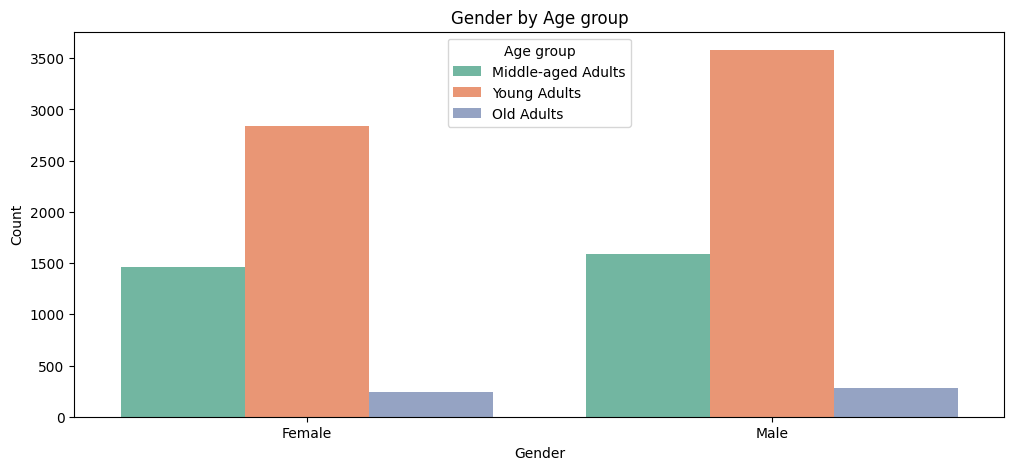

In [54]:
plt.figure(figsize=(12, 5))
sns.countplot(data = df, x = 'Gender', hue='Age group', palette='Set2')
plt.title('Gender by Age group')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

##### **In both genders, Young Adults are the most represented age group, followed by Middle-aged Adults, and then Old Adults.**

##### **The total count of males is higher than the total count of females. This is evident as the bars for each age group are consistently taller for males than for females.**

##### **The distribution of age groups is similar for both genders, with the counts of Young Adults being significantly higher than Middle-aged Adults, and Old Adults being the smallest group.**


- #### **Comparison of Churn probability between Age groups**

In [56]:
df['Age group'].value_counts()

Age group
Young Adults          6419
Middle-aged Adults    3055
Old Adults             526
Name: count, dtype: int64

In [59]:
p_old_adults_given_churned = len(df[(df['Churned']=='Exited') & (df['Age group']=='Old Adults')])/len(df[df['Churned']=='Exited'])
print(f'P(old adults ∣ churned) : {p_old_adults_given_churned*100:.2f} %')

P(old adults ∣ churned) : 7.22 %


In [60]:
p_intersection_old_adults_churn = p_churn * p_old_adults_given_churned
print(f'P(churned ∩ old adults) : {p_intersection_old_adults_churn*100:.2f} %')

P(churned ∩ old adults) : 1.47 %


-----------------------------

- ##### **Credit Score Distribution by Gender**

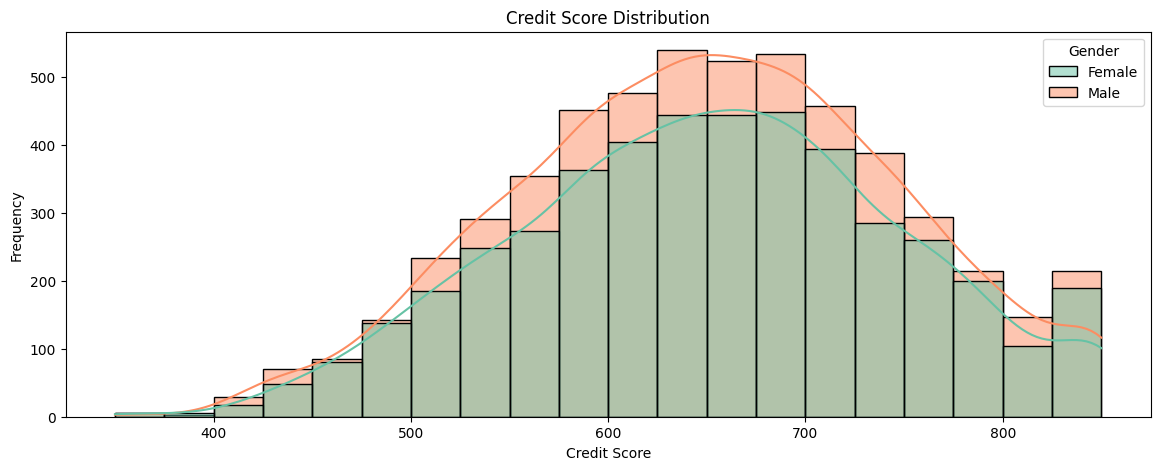

In [ ]:
plt.figure(figsize=(14, 5))
sns.histplot(data=df, x='Credit Score', hue='Gender', kde=True, bins=20, palette='Set2')
plt.title('Credit Score Distribution')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')
plt.show()

##### **the distribution of credit scores for both males and females follows a nearly identical and expected bell-shaped curve, centered around scores of 600-650. While there is a subtle trend showing a slightly higher frequency of males in the lower score ranges and a slightly higher frequency of females in the upper ranges, the overall distributions are remarkably similar. This indicates that gender is not a significant differentiating factor in credit score outcomes for this dataset, suggesting the scoring model is effectively neutral towards gender as intended.**
-------------------------------------

- ##### **Comparison of Geography Between Males and Females**

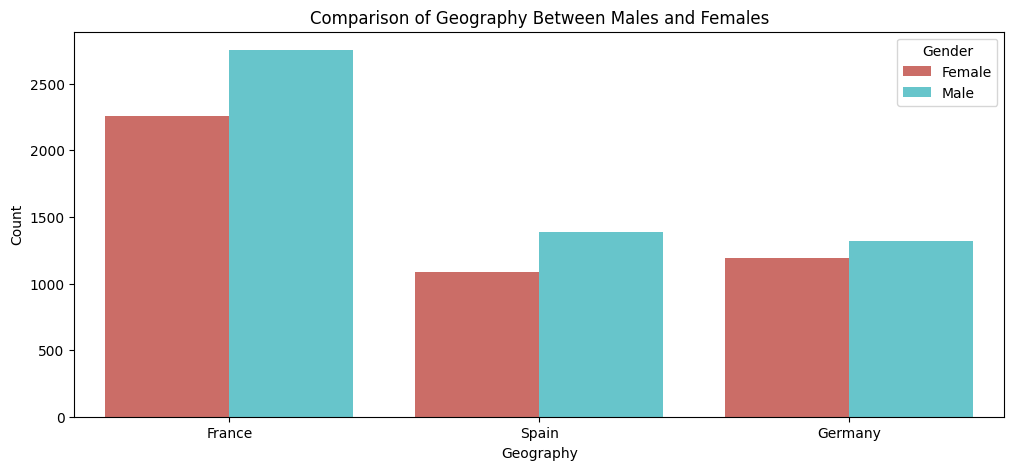

In [ ]:
plt.figure(figsize=(12, 5))
sns.countplot(data = df, x ='Geography', hue='Gender',palette='hls')
plt.title('Comparison of Geography Between Males and Females')
plt.xlabel('Geography')
plt.ylabel('Count')
plt.show()

##### **This analysis of the bank's customer base reveals geographic differences in its appeal to different genders: its clientele in France is predominantly male, in Spain is predominantly male, and in Germany it is perfectly balanced. This indicates that the bank's products, services, or marketing strategies resonate differently with men and women depending on the country.**
------------------------

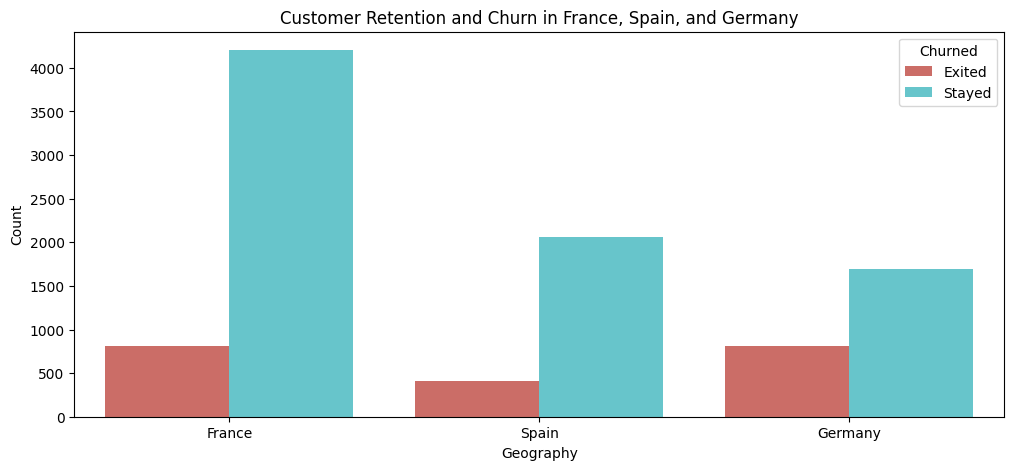

In [ ]:
plt.figure(figsize=(12, 5))
sns.countplot(data = df, x ='Geography', hue='Churned',palette='hls')
plt.title('Customer Retention and Churn in France, Spain, and Germany')
plt.xlabel('Geography')
plt.ylabel('Count')
plt.show()

- ##### **France has the largest total customer base.**

- ##### **The number of customers who exited is roughly the same for France and Germany, despite France having a much larger total customer base.**

- ##### **The number of customers who exited is the lowest in Spain.**

- ##### **When looking at the proportion of customers who exited, Germany has the highest churn rate, followed by France. Spain has the lowest churn rate.**
---------------------------------

- ##### **Comparison of Estimated Salary Category Between Males and Females**

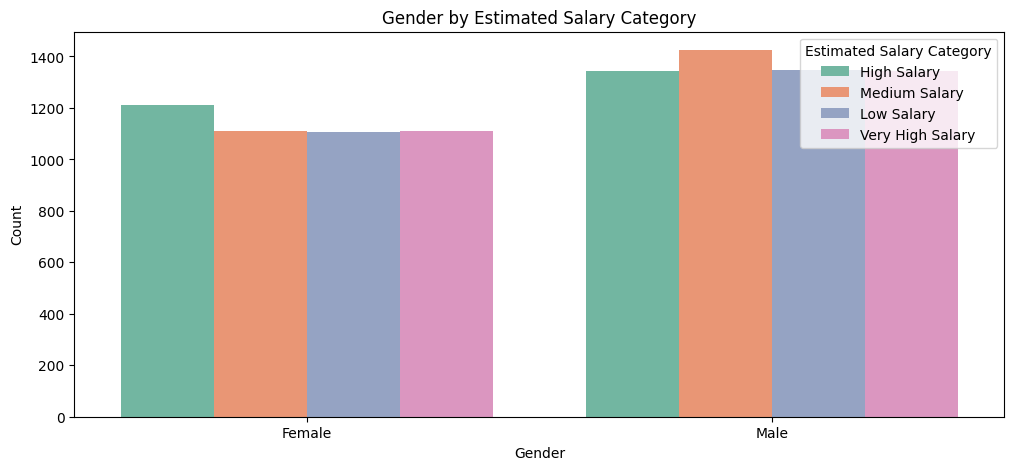

In [ ]:
plt.figure(figsize=(12, 5))
sns.countplot(data = df, x = 'Gender', hue='Estimated Salary Category',palette='Set2')
plt.title('Gender by Estimated Salary Category')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

- ##### **The total number of males is higher than the total number of females. This is evident as all the bars for males are taller than their female counterparts.**

- ##### **The distribution of salary categories for both genders is relatively flat, with all categories having similar counts.**

- ##### **However, males show a slightly greater concentration in the High and Medium salary ranges compared to females, where the distribution is more evenly spread across all four categories.**
-----------------------

### ***Correlation analysis of factors with customer exit***
------------------------

- ##### **Comparison of the average age between customers who left and those who stayed**

In [ ]:
ChurnedByAvgAge = df.groupby(by ='Churned')['Age'].mean()
ChurnedByAvgAge

Churned
Exited    44.837997
Stayed    37.408389
Name: Age, dtype: float64

C:\Users\RPC\AppData\Local\Temp\ipykernel_13828\1652411189.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Churned', y='Age', data=age_data, palette='viridis')


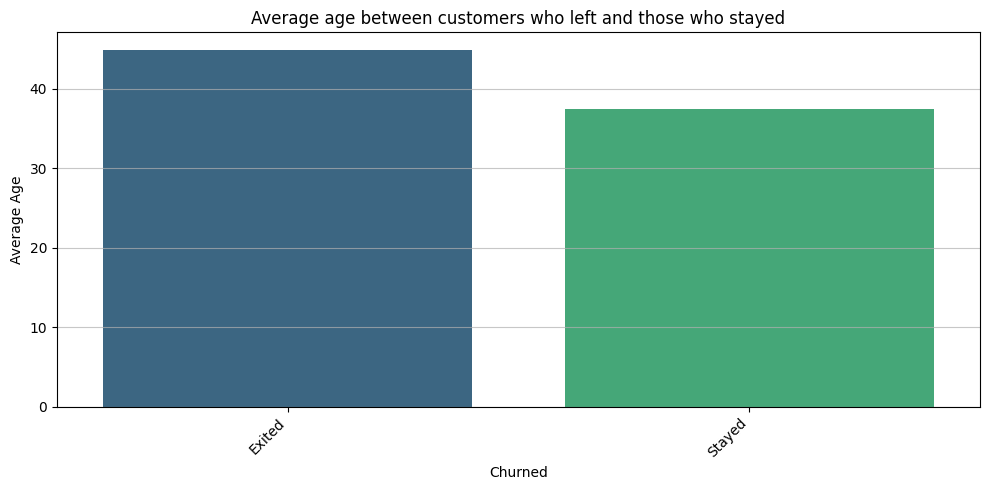

In [ ]:
age_data = pd.DataFrame(ChurnedByAvgAge)

age_data = age_data.sort_values(by='Age', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Churned', y='Age', data=age_data, palette='viridis')
plt.title('Average age between customers who left and those who stayed')
plt.xlabel('Churned')
plt.ylabel('Average Age')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.7)
plt.tight_layout()
plt.show()

-----------------------------------
- ##### **Comparison of the average balance between customers who left and those who stayed.**

In [ ]:
ChurnedByAvgBalance = df.groupby(by ='Churned')['Balance'].mean()
ChurnedByAvgBalance

Churned
Exited    91108.539337
Stayed    72745.296779
Name: Balance, dtype: float64

C:\Users\RPC\AppData\Local\Temp\ipykernel_13828\751184331.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Churned', y='Balance', data=age_data, palette='Set1')


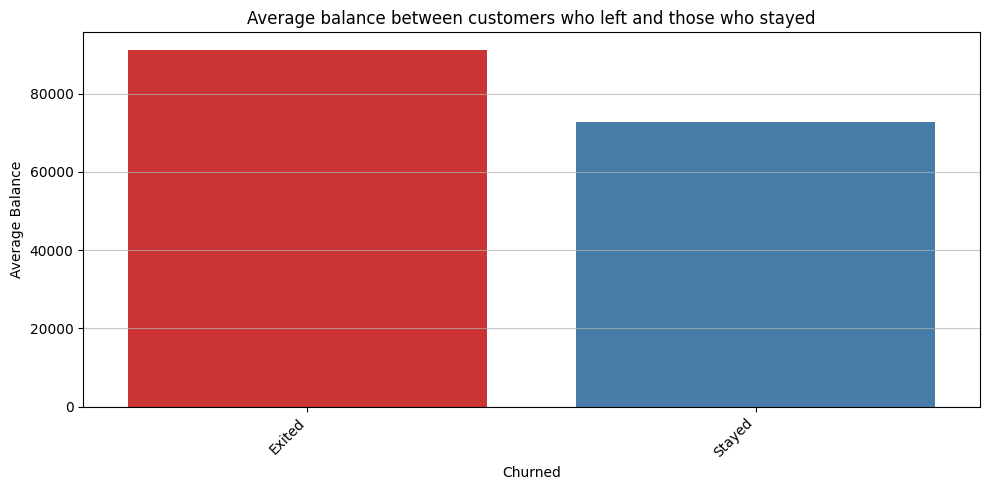

In [ ]:
age_data = pd.DataFrame(ChurnedByAvgBalance)

age_data = age_data.sort_values(by='Balance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Churned', y='Balance', data=age_data, palette='Set1')
plt.title('Average balance between customers who left and those who stayed')
plt.xlabel('Churned')
plt.ylabel('Average Balance')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.7)
plt.tight_layout()
plt.show()

- ##### **This bar chart reveals a critical and alarming insight: customers who churned had a significantly higher average account balance than those who remained. This means the bank is failing to retain its most valuable, high-asset customers, which directly threatens its profitability and stability. The likely cause is that competitors are offering better service, more competitive interest rates, or more attractive terms to this desirable segment. The bank must immediately shift its retention strategy to focus on understanding and addressing the needs of its high-balance customers to prevent further loss of its most important assets.**
------------------------------

- ##### **Comparison of Credit Score Category Between customers who left and those who stayed**

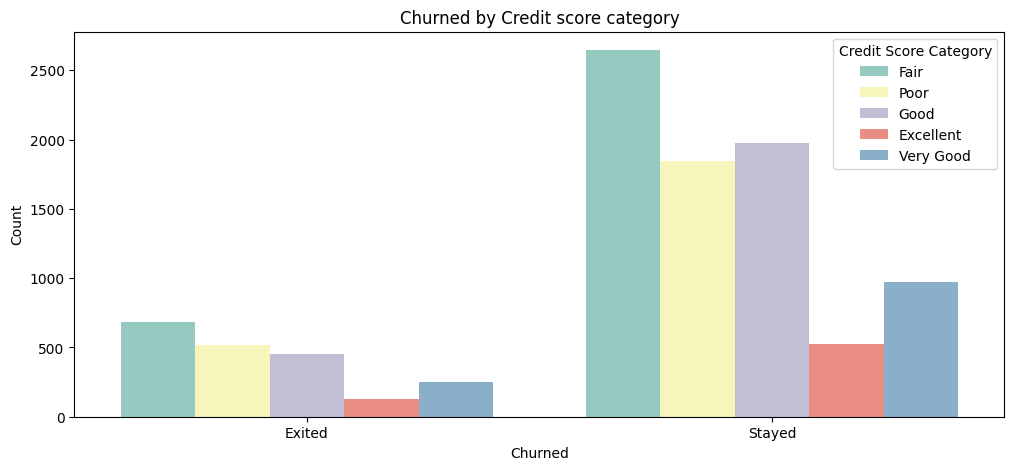

In [ ]:
plt.figure(figsize=(12, 5))
sns.countplot(data = df, x ='Churned', hue='Credit Score Category', palette='Set3')
plt.title('Churned by Credit score category')
plt.xlabel('Churned')
plt.ylabel('Count')
plt.show()

##### **Number of customers in each credit score group for both exited and stayed customers. While the highest number of customers in both groups fall into the "Fair" credit score category, the proportional distribution of credit scores is very similar for both churned and retained customers. This indicates that a customer's credit score may not be a significant predictor of whether they will churn. Churn is present across all credit score categories, with no single group being disproportionately more likely to exit.**
----------------------------

- ##### **Effect of having credit card on the possibility of leaving**

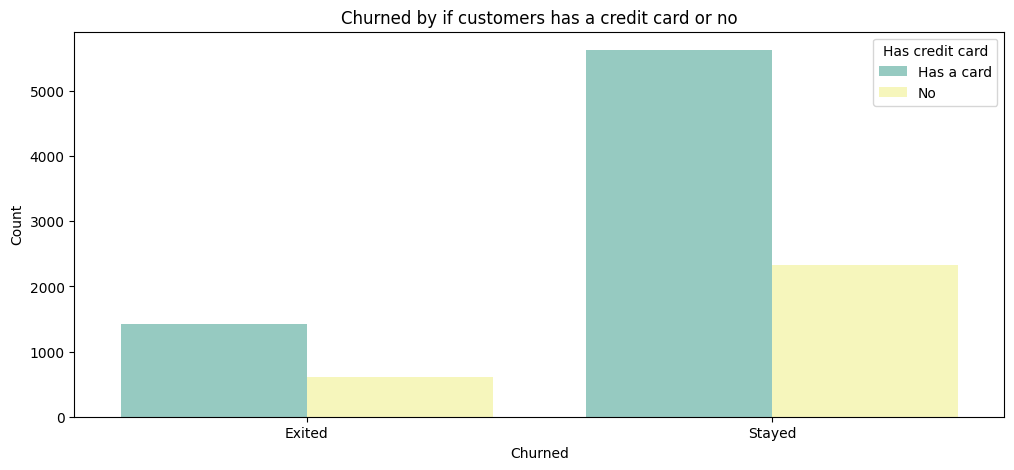

In [ ]:
plt.figure(figsize=(12, 5))
sns.countplot(data = df, x ='Churned', hue='Has credit card', palette='Set3')
plt.title('Churned by if customers has a credit card or no')
plt.xlabel('Churned')
plt.ylabel('Count')
plt.show()

#### **The chart shows that the total number of leavers who are cardholders is larger simply because there are more of them to begin with. But when we look at the risk for each individual customer, we find that:**

- ##### **A customer who has a credit card has a higher probability (27%) of leaving.**

- ##### **A customer who does not have a credit card has a lower probability (20%) of leaving.**

#### **Therefore, having a credit card is associated with an increased risk of customer churn, and not having one is a minor factor that helps retain the customer. You are seeing the total number, but the important part is the proportion within each group.**

------------------------------------

- ##### **Effect of active member or no on the possibility of leaving**

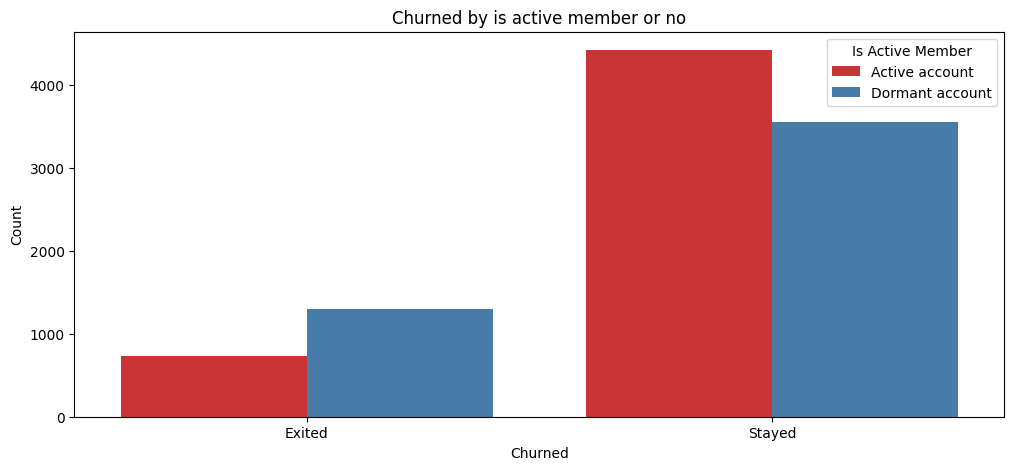

In [ ]:
plt.figure(figsize=(12, 5))
sns.countplot(data = df, x ='Churned', hue='Is Active Member', palette='Set1')
plt.title('Churned by is active member or no')
plt.xlabel('Churned')
plt.ylabel('Count')
plt.show()

- ##### **Customers with a dormant account have an extremely high estimated churn rate of ~60%. This means a customer who is not active has a very high possibility of leaving.**

- ##### **Conversely, customers with an active account have a very low estimated churn rate of ~12.5%.**

##### **Therefore, being an inactive (dormant) member is the strongest predictor of customer churn visible in this chart. Activity status is a critically important factor; an inactive customer is several times more likely to leave than an active one.**
-----------------------

### ***Study Customer behavior***
-------------------

- ##### **Do customers with Num Of Products = 1 tend to leave more or less often ?**

In [ ]:
nmbOfProdEq1 = df[df['Number Of Products']==1]
nmbOfProdEq1

,Credit Score,Geography,Gender,Age,Tenure,Balance,Number Of Products,Has credit card,Is Active Member,Estimated Salary,Churned,Age group,Balance category,Credit Score Category,Estimated Salary Category,BalanceSalaryRatio
0,619,France,Female,42,2,0.00,1,Has a card,Active account,101348.88,Exited,Middle-aged Adults,Empty account,Fair,High Salary,0.000000
1,608,Spain,Female,41,1,83807.86,1,No,Active account,112542.58,Stayed,Middle-aged Adults,Funded account,Fair,High Salary,0.744677
4,850,Spain,Female,43,2,125510.82,1,Has a card,Active account,79084.10,Stayed,Middle-aged Adults,Funded account,Excellent,Medium Salary,1.587055
9,684,France,Male,27,2,134603.88,1,Has a card,Active account,71725.73,Stayed,Young Adults,Funded account,Good,Medium Salary,1.876647
16,653,Germany,Male,58,1,132602.88,1,Has a card,Dormant account,5097.67,Exited,Middle-aged Adults,Funded account,Fair,Low Salary,26.012449
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,726,Spain,Male,36,2,0.00,1,Has a card,Dormant account,195192.40,Stayed,Young Adults,Empty account,Good,Very High Salary,0.000000
9993,644,France,Male,28,7,155060.41,1,Has a card,Dormant account,29179.52,Stayed,Young Adults,Funded account,Fair,Low Salary,5.314015
9996,516,France,Male,35,10,57369.61,1,Has a card,Active account,101699.77,Stayed,Young Adults,Funded account,Poor,High Salary,0.564108
9997,709,France,Female,36,7,0.00,1,No,Active account,42085.58,Exited,Young Adults,Empty account,Good,Low Salary,0.000000


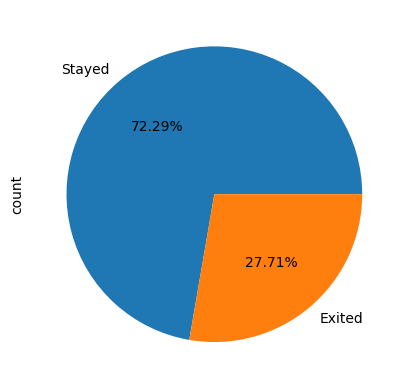

In [ ]:
nmbOfProdEq1['Churned'].value_counts().plot.pie(autopct='%0.2f%%')
plt.show()

---------------------------

- ##### **Do customers with Num Of Products = 2 or more tend to leave more or less often ?**

In [ ]:
nmbOfProdGte2 = df[df['Number Of Products']>=2]
nmbOfProdGte2

,Credit Score,Geography,Gender,Age,Tenure,Balance,Number Of Products,Has credit card,Is Active Member,Estimated Salary,Churned,Age group,Balance category,Credit Score Category,Estimated Salary Category,BalanceSalaryRatio
2,502,France,Female,42,8,159660.80,3,Has a card,Dormant account,113931.57,Exited,Middle-aged Adults,Funded account,Poor,High Salary,1.401375
3,699,France,Female,39,1,0.00,2,No,Dormant account,93826.63,Stayed,Young Adults,Empty account,Good,Medium Salary,0.000000
5,645,Spain,Male,44,8,113755.78,2,Has a card,Dormant account,149756.71,Exited,Middle-aged Adults,Funded account,Fair,High Salary,0.759604
6,822,France,Male,50,7,0.00,2,Has a card,Active account,10062.80,Stayed,Middle-aged Adults,Empty account,Excellent,Low Salary,0.000000
7,376,Germany,Female,29,4,115046.74,4,Has a card,Dormant account,119346.88,Exited,Young Adults,Funded account,Poor,High Salary,0.963969
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9988,775,France,Male,30,4,0.00,2,Has a card,Dormant account,49337.84,Stayed,Young Adults,Empty account,Very Good,Low Salary,0.000000
9989,841,Spain,Male,28,4,0.00,2,Has a card,Active account,179436.60,Stayed,Young Adults,Empty account,Excellent,Very High Salary,0.000000
9994,800,France,Female,29,2,0.00,2,No,Dormant account,167773.55,Stayed,Young Adults,Empty account,Excellent,Very High Salary,0.000000
9995,771,France,Male,39,5,0.00,2,Has a card,Dormant account,96270.64,Stayed,Young Adults,Empty account,Very Good,Medium Salary,0.000000


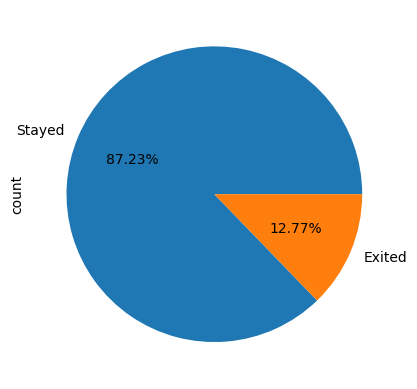

In [ ]:
nmbOfProdGte2['Churned'].value_counts().plot.pie(autopct='%0.2f%%')
plt.show()

----------------------------------

- ##### **Do customers with tenure < 3 years tend to leave more or less often ?**

In [ ]:
tenureLt3years = df[df['Tenure']<3]
tenureLt3years

,Credit Score,Geography,Gender,Age,Tenure,Balance,Number Of Products,Has credit card,Is Active Member,Estimated Salary,Churned,Age group,Balance category,Credit Score Category,Estimated Salary Category,BalanceSalaryRatio
0,619,France,Female,42,2,0.00,1,Has a card,Active account,101348.88,Exited,Middle-aged Adults,Empty account,Fair,High Salary,0.000000
1,608,Spain,Female,41,1,83807.86,1,No,Active account,112542.58,Stayed,Middle-aged Adults,Funded account,Fair,High Salary,0.744677
3,699,France,Female,39,1,0.00,2,No,Dormant account,93826.63,Stayed,Young Adults,Empty account,Good,Medium Salary,0.000000
4,850,Spain,Female,43,2,125510.82,1,Has a card,Active account,79084.10,Stayed,Middle-aged Adults,Funded account,Excellent,Medium Salary,1.587055
9,684,France,Male,27,2,134603.88,1,Has a card,Active account,71725.73,Stayed,Young Adults,Funded account,Good,Medium Salary,1.876647
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9975,610,Germany,Male,50,1,113957.01,2,Has a card,Dormant account,196526.55,Exited,Middle-aged Adults,Funded account,Fair,Very High Salary,0.579856
9979,677,France,Female,58,1,90022.85,1,No,Active account,2988.28,Stayed,Middle-aged Adults,Funded account,Good,Low Salary,30.125306
9986,673,Germany,Male,47,1,183579.54,2,No,Active account,34047.54,Stayed,Middle-aged Adults,Funded account,Good,Low Salary,5.391859
9992,726,Spain,Male,36,2,0.00,1,Has a card,Dormant account,195192.40,Stayed,Young Adults,Empty account,Good,Very High Salary,0.000000


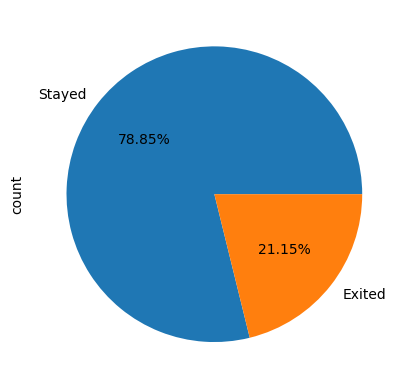

In [ ]:
tenureLt3years['Churned'].value_counts().plot.pie(autopct='%0.2f%%')
plt.show()

---------------------------
- ##### **Do customers with tenure = 3 years or more tend to leave more or less often ?**

In [ ]:
tenureGte3years = df[df['Tenure']>=3]
tenureGte3years

,Credit Score,Geography,Gender,Age,Tenure,Balance,Number Of Products,Has credit card,Is Active Member,Estimated Salary,Churned,Age group,Balance category,Credit Score Category,Estimated Salary Category,BalanceSalaryRatio
2,502,France,Female,42,8,159660.80,3,Has a card,Dormant account,113931.57,Exited,Middle-aged Adults,Funded account,Poor,High Salary,1.401375
5,645,Spain,Male,44,8,113755.78,2,Has a card,Dormant account,149756.71,Exited,Middle-aged Adults,Funded account,Fair,High Salary,0.759604
6,822,France,Male,50,7,0.00,2,Has a card,Active account,10062.80,Stayed,Middle-aged Adults,Empty account,Excellent,Low Salary,0.000000
7,376,Germany,Female,29,4,115046.74,4,Has a card,Dormant account,119346.88,Exited,Young Adults,Funded account,Poor,High Salary,0.963969
8,501,France,Male,44,4,142051.07,2,No,Active account,74940.50,Stayed,Middle-aged Adults,Funded account,Poor,Medium Salary,1.895518
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,Has a card,Dormant account,96270.64,Stayed,Young Adults,Empty account,Very Good,Medium Salary,0.000000
9996,516,France,Male,35,10,57369.61,1,Has a card,Active account,101699.77,Stayed,Young Adults,Funded account,Poor,High Salary,0.564108
9997,709,France,Female,36,7,0.00,1,No,Active account,42085.58,Exited,Young Adults,Empty account,Good,Low Salary,0.000000
9998,772,Germany,Male,42,3,75075.31,2,Has a card,Dormant account,92888.52,Exited,Middle-aged Adults,Funded account,Very Good,Medium Salary,0.808230


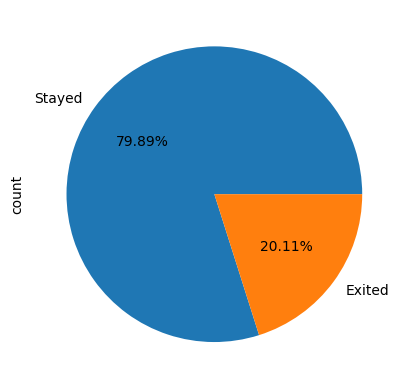

In [ ]:
tenureGte3years['Churned'].value_counts().plot.pie(autopct='%0.2f%%')
plt.show()

-----------------------------------

- ##### **Relationship between balance and churn**

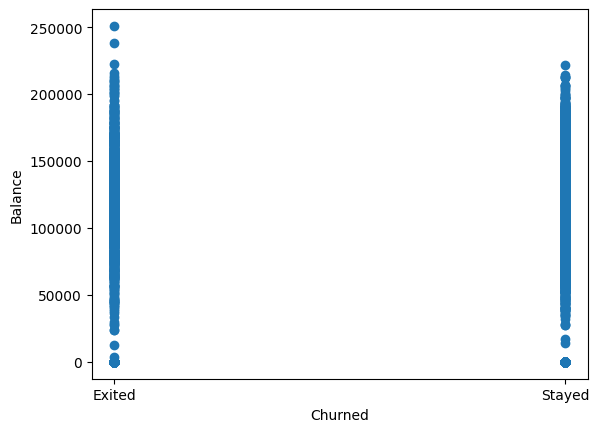

In [ ]:
plt.scatter(df['Churned'], df['Balance'])
plt.xlabel('Churned')
plt.ylabel('Balance')
plt.show()

- ##### **More Options**: Wealthier customers with higher balances are likely more attractive targets for competitors' offers and may have more financial products (e.g., investments, accounts at other banks), making it easier for them to switch.

- ##### **Higher Expectations**: Customers with larger balances may have higher expectations for service, interest rates, and perks. If the bank fails to meet these expectations, they are more likely to take their business elsewhere.

- ##### **Financial Activity**: A high balance might be associated with a one-time event (e.g., selling a house, receiving an inheritance) after which the customer closes the account.

##### High balance is a major risk factor for customer churn. The bank should pay special attention to retaining its high-value customers, as they are the most likely to leave.

-----------------------------------------

### ***Segmentation and analysis***
------------------------

- ##### **Comparison of Age group Between who stayed and who left**

In [ ]:
countOfChurnedOrNoByAgeGroup = pd.crosstab(df['Age group'], df['Churned'])
countOfChurnedOrNoByAgeGroup

Churned,Exited,Stayed
Age group,,
Middle-aged Adults,1204,1851
Old Adults,147,379
Young Adults,686,5733


In [ ]:
val1 = countOfChurnedOrNoByAgeGroup.iloc[0,:1].values
val2 = countOfChurnedOrNoByAgeGroup.iloc[0,1:2].values

summ = val1 + val2
p = (val1/summ)*100
p2 = (val2/summ)*100
print('Exited Middle-aged Adults',p,'%')
print('Stayed Middle-aged Adults',p2,'%')

Exited Middle-aged Adults [39.41080196] %
Stayed Middle-aged Adults [60.58919804] %


In [ ]:
val1 = countOfChurnedOrNoByAgeGroup.iloc[1,:1].values
val2 = countOfChurnedOrNoByAgeGroup.iloc[1,1:2].values

summ = val1 + val2
p = (val1/summ)*100
p2 = (val2/summ)*100
print('Exited Old Adults',p,'%')
print('Stayed Old Adults',p2,'%')

Exited Old Adults [27.94676806] %
Stayed Old Adults [72.05323194] %


In [ ]:
val1 = countOfChurnedOrNoByAgeGroup.iloc[2,:1].values
val2 = countOfChurnedOrNoByAgeGroup.iloc[2,1:2].values

summ = val1 + val2
p = (val1/summ)*100
p2 = (val2/summ)*100
print('Exited Young Adults',p,'%')
print('Stayed Young Adults',p2,'%')

Exited Young Adults [10.6870229] %
Stayed Young Adults [89.3129771] %


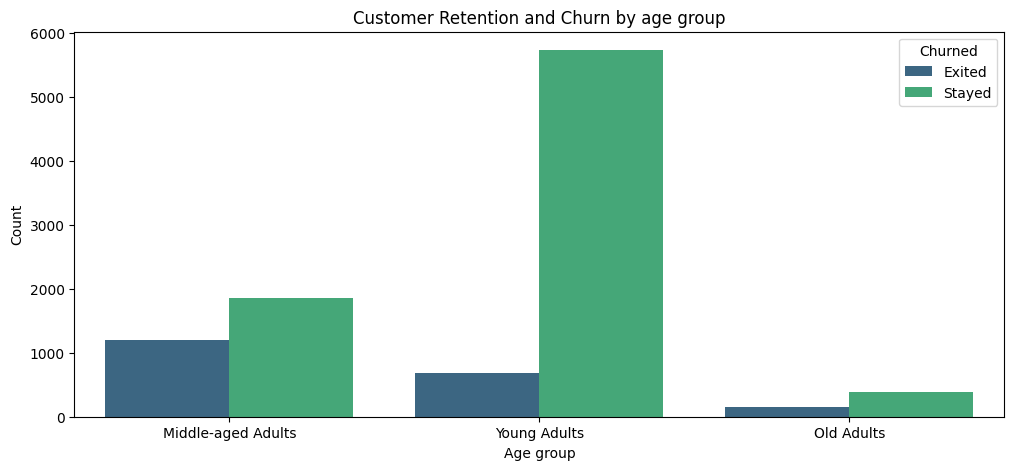

In [ ]:
plt.figure(figsize=(12, 5))
sns.countplot(data = df, x ='Age group', hue='Churned',palette='viridis')
plt.title('Customer Retention and Churn by age group')
plt.xlabel('Age group')
plt.ylabel('Count')
plt.show()

- ##### **Young Adults:** This group has the highest number of customers overall and shows the strongest retention. The number of stayed young adults is significantly higher than those who exited, indicating they are the most loyal customer base.

- ##### **Middle-aged Adults:** This group has the highest number of customers who have churned, with approximately 1,200 exiting. This suggests a significant churn risk within this demographic.

- ##### **Old Adults:** While this group has the lowest total number of customers, they also show a high churn rate relative to their size, indicating they are more prone to leaving.
----------------------------------

- ##### **Churn Rate by Geography and Credit Score Group**

In [ ]:
df['Churned'].unique()

array(['Exited', 'Stayed'], dtype=object)

In [ ]:
df['Churned_numeric'] = df['Churned'].map({'Exited': 1, 'Stayed': 0})
df['Churned_numeric']

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Churned_numeric, Length: 10000, dtype: int64

In [ ]:
# Verify the conversion
print("Unique values in Churned_numeric column:", df['Churned_numeric'].unique())
print(f"Churn rate: {df['Churned_numeric'].mean()*100:.2f}%")

Unique values in Churned_numeric column: [1 0]
Churn rate: 20.37%


In [ ]:
# Check the unique values in the 'Geography' column
print("Countries in the dataset:", df['Geography'].unique())

Countries in the dataset: ['France' 'Spain' 'Germany']


In [ ]:
# Get basic statistics for CreditScore by Country
print("\nCredit Score statistics by country:")
print(df.groupby('Geography')['Credit Score Category'].describe())


Credit Score statistics by country:
          count unique   top  freq
Geography                         
France     5014      5  Fair  1621
Germany    2509      5  Fair   861
Spain      2477      5  Fair   849


In [ ]:
# Define a threshold for "low" credit score (bottom 25th percentile)
low_score_threshold = df['Credit Score'].quantile(0.25)
print(f"\nLow Credit Score Threshold (25th percentile): {low_score_threshold}")


Low Credit Score Threshold (25th percentile): 584.0


In [ ]:
# Create a new column to flag customers with low credit scores
df['LowCreditScore'] = df['Credit Score'] < low_score_threshold
df['LowCreditScore']

0       False
1       False
2        True
3       False
4       False
        ...  
9995    False
9996     True
9997    False
9998    False
9999    False
Name: LowCreditScore, Length: 10000, dtype: bool

In [ ]:
# Create a summary table using the numeric column
churn_analysis = df.groupby(['Geography', 'LowCreditScore'])['Churned_numeric'].agg(['mean', 'count', 'sum'])
churn_analysis['mean'] = churn_analysis['mean'] * 100 # Convert to percentage
churn_analysis = churn_analysis.rename(columns={
    'mean': 'ChurnRate (%)', 
    'sum': 'Num_Churned', 
    'count': 'Total_Customers'
})

print("\nChurn Analysis by Geography and Credit Score Group:")
print(churn_analysis)


Churn Analysis by Geography and Credit Score Group:
                          ChurnRate (%)  Total_Customers  Num_Churned
Geography LowCreditScore                                             
France    False               15.679443             3731          585
          True                17.537023             1283          225
Germany   False               31.378764             1893          594
          True                35.714286              616          220
Spain     False               16.445623             1885          310
          True                17.398649              592          103


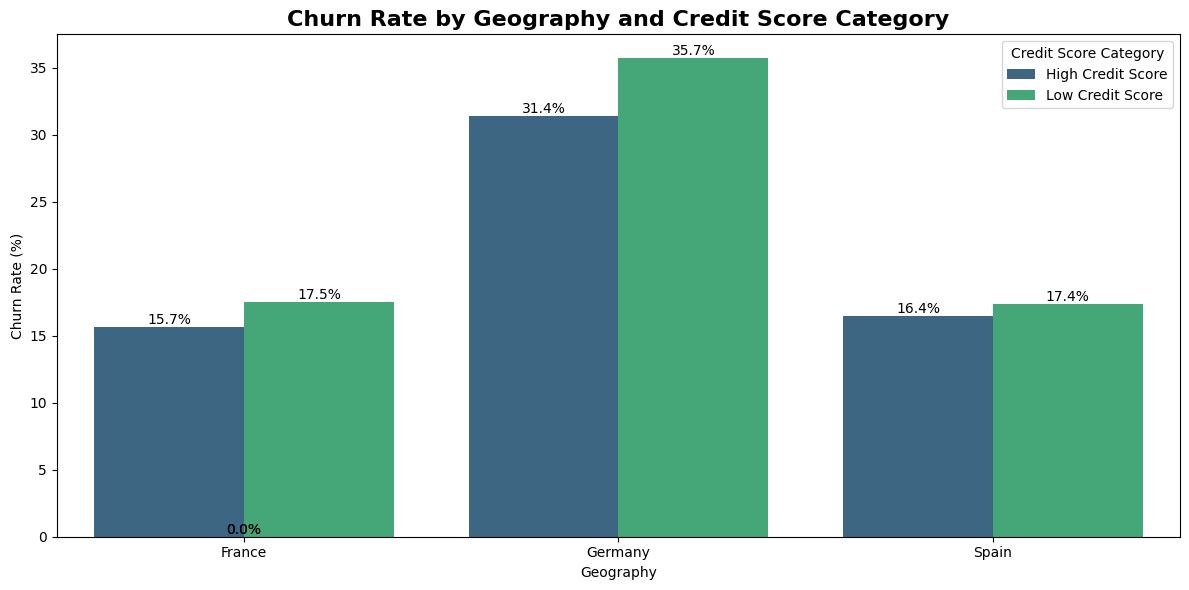

In [ ]:
# Prepare data for plotting
pivot_df = df.groupby(['Geography', 'LowCreditScore'])['Churned_numeric'].mean().reset_index()
pivot_df['Churned_numeric'] = pivot_df['Churned_numeric'] * 100 # Convert to percentage

# Create the plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Geography', y='Churned_numeric', hue='LowCreditScore', 
                 data=pivot_df, palette='viridis')

plt.title('Churn Rate by Geography and Credit Score Category', fontsize=16, fontweight='bold')
plt.xlabel('Geography')
plt.ylabel('Churn Rate (%)')

# Customize legend labels
legend_labels = ['High Credit Score', 'Low Credit Score']
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, legend_labels, title='Credit Score Category')

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

##### **Customers with low credit scores are significantly more likely to churn, and this pattern holds true across all three countries. The risk is most severe in Germany and Spain, where approximately 35% of low credit score customers churn. France shows the same trend but with a slightly lower overall churn rate.**

In [ ]:
# Test for a specific country, e.g., Germany
country_to_test = 'Germany'

germany_data = df[df['Geography'] == country_to_test]
germany_low = germany_data[germany_data['LowCreditScore']]['Churned_numeric']
germany_high = germany_data[~germany_data['LowCreditScore']]['Churned_numeric']

print(f"\nStatistical test for {country_to_test}:")
print(f"Low credit score group: {len(germany_low)} customers, churn rate: {germany_low.mean()*100:.1f}%")
print(f"High credit score group: {len(germany_high)} customers, churn rate: {germany_high.mean()*100:.1f}%")

# Perform T-test
t_stat, p_value = stats.ttest_ind(germany_low, germany_high, alternative='greater')

print(f"T-test: t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")
if p_value < 0.05:
    print("The difference is statistically significant.")
else:
    print("The difference is not statistically significant.")


Statistical test for Germany:
Low credit score group: 616 customers, churn rate: 35.7%
High credit score group: 1893 customers, churn rate: 31.4%
T-test: t-statistic = 1.9972, p-value = 0.0230
The difference is statistically significant.


-------------------------------

- ##### **Distribution of Salary by Age Group and Churn Status for young adults**

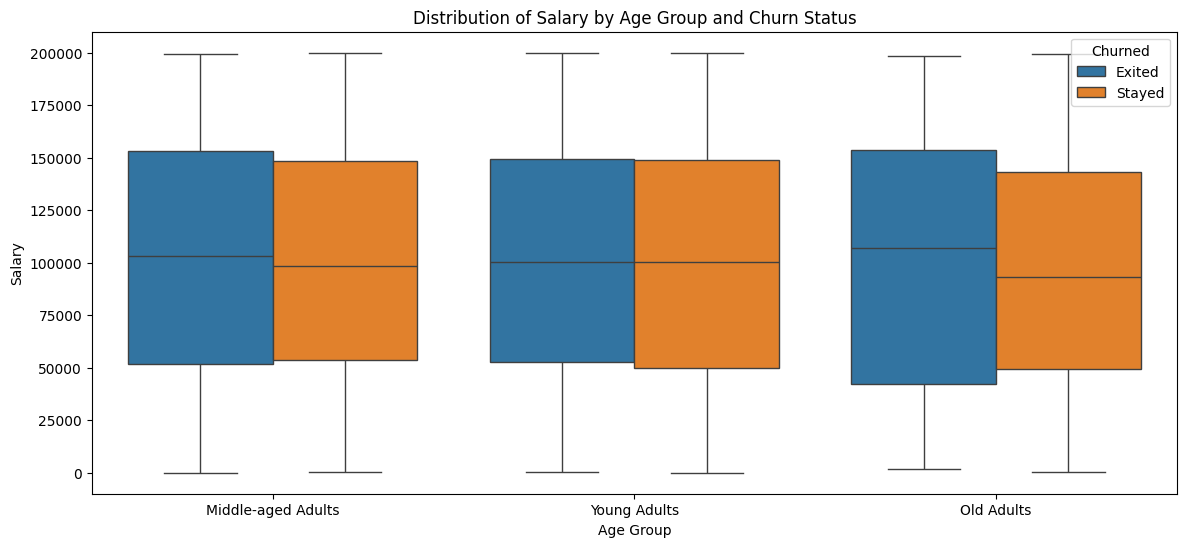

In [ ]:
plt.figure(figsize=(14, 6))
# Create a boxplot of Salary, split by AgeGroup and Churn status
sns.boxplot(data=df, x='Age group', y='Estimated Salary', hue='Churned', showfliers=False) # showfliers=False removes outliers for a clearer view
plt.title('Distribution of Salary by Age Group and Churn Status')
plt.ylabel('Salary')
plt.xlabel('Age Group')
plt.show()

- ##### **This phenomenon primarily applies to the Young Adults group.**

- ##### **What does this mean? It's likely that high-performing young employees (which is reflected in their higher salaries) are being poached by competitors with better offers or feel undervalued, prompting them to leave.**

#### **Recommendation : HR management or customer retention strategies should urgently focus on retention policies for high-performing young talent.**

-------------------------------
-------------------------------


# <center><strong>Conclusion</strong></center>
--------------------------------------------
#### **This analysis of Bank Customer Churn provided valuable insights into the patterns and factors influencing customer retention. By exploring the dataset, we observed key trends such as the impact of tenure, contract type, and service usage on churn behavior. The results highlight the importance of customer profiling and segmentation in understanding churn dynamics, and they serve as a foundation for more advanced predictive modeling in future work. Overall, this analysis demonstrates how data-driven insights can guide strategies to reduce churn and improve customer satisfaction.**

---------------------------------------

In [ ]:
# !jupyter nbconvert --to html "bank customer churn analysis.ipynb"

[NbConvertApp] Converting notebook bank customer churn analysis.ipynb to html
C:\Users\RPC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\nbformat\__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)
[NbConvertApp] WARNING | Alternative text is missing on 31 image(s).
[NbConvertApp] Writing 1553483 bytes to bank customer churn analysis.html
